# Interpretation — what actually drives house prices

Three sources of feature importance:
1. **RandomForest's built-in feature importance** (at the post-preprocessing feature level — one-hot categories are counted separately).
2. **Ridge coefficients** (same feature level).
3. **Permutation importance** — on the raw original columns, through the full `Pipeline` (feature engineering + preprocessing + model). This is the most reliable and most interpretable approach: a categorical feature like `Neighborhood` is scored as a single column instead of dozens of one-hot dummies.

Models are trained on 80% of the data; feature importance and the "predicted vs actual" charts are computed on the held-out 20% — an honest, out-of-sample estimate.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from preprocessing import TARGET_COL, build_full_pipeline, load_train_test
from interpret import HUMAN_LABELS, aggregate_by_base_feature, get_output_feature_names, raw_permutation_importance

sns.set_style("whitegrid")

train_df, _ = load_train_test("../data")
X = train_df.drop(columns=[TARGET_COL])
y = np.log1p(train_df[TARGET_COL])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"train={X_train.shape}, test={X_test.shape}")

train=(1166, 80), test=(292, 80)


## Training models with the best hyperparameters from Stage 3

Ridge (`alpha=20`), RandomForest (`n_estimators=400, max_depth=None`), HistGradientBoosting (`learning_rate=0.05, max_depth=6, max_iter=200`) — the same values `GridSearchCV` picked in [02_modeling.ipynb](02_modeling.ipynb).

In [2]:
pipelines = {
    "Ridge": Pipeline(build_full_pipeline(X_train).steps + [("model", Ridge(alpha=20, random_state=42))]),
    "RandomForest": Pipeline(build_full_pipeline(X_train).steps + [("model", RandomForestRegressor(
        n_estimators=400, max_depth=None, random_state=42, n_jobs=-1))]),
    "HistGradientBoosting": Pipeline(build_full_pipeline(X_train).steps + [("model", HistGradientBoostingRegressor(
        learning_rate=0.05, max_depth=6, max_iter=200, random_state=42))]),
}

test_scores = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    test_scores[name] = {"rmse_log": rmse, "r2": r2}
    print(f"{name}: held-out RMSE(log)={rmse:.4f}, R2={r2:.4f}")

Ridge: held-out RMSE(log)=0.1233, R2=0.9098


RandomForest: held-out RMSE(log)=0.1430, R2=0.8787


HistGradientBoosting: held-out RMSE(log)=0.1318, R2=0.8970


## 1. Built-in feature importance — RandomForest

At the post-preprocessing feature level (categories are separate one-hot columns).

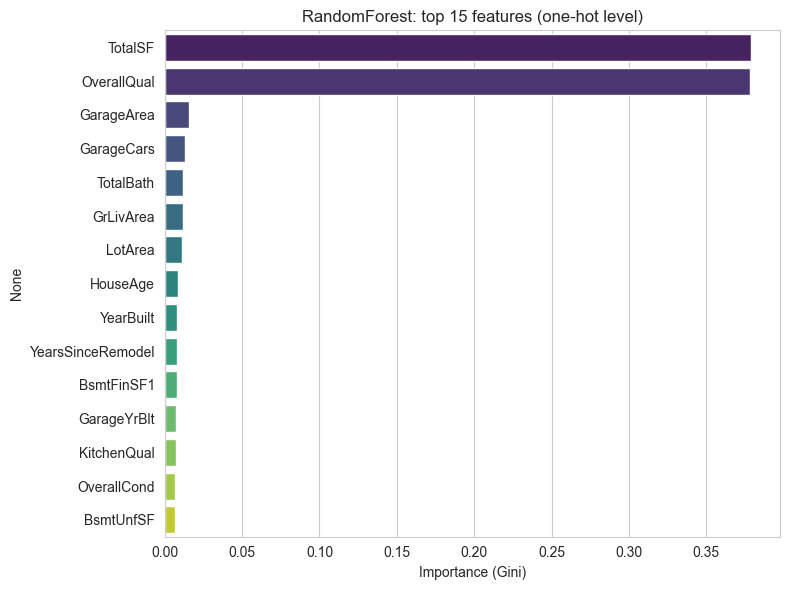

TotalSF              0.378699
OverallQual          0.378419
GarageArea           0.015406
GarageCars           0.012798
TotalBath            0.011730
GrLivArea            0.011653
LotArea              0.011202
HouseAge             0.008463
YearBuilt            0.008213
YearsSinceRemodel    0.008162
BsmtFinSF1           0.008027
GarageYrBlt          0.007429
KitchenQual          0.007095
OverallCond          0.006821
BsmtUnfSF            0.006628
dtype: float64

In [3]:
rf_pipe = pipelines["RandomForest"]
rf_ct = rf_pipe.named_steps["preprocess"]
display_names, base_names = get_output_feature_names(rf_ct)

rf_importances = pd.Series(rf_pipe.named_steps["model"].feature_importances_, index=display_names)
rf_top = rf_importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=rf_top.values, y=rf_top.index, hue=rf_top.index, palette="viridis", legend=False)
plt.xlabel("Importance (Gini)")
plt.title("RandomForest: top 15 features (one-hot level)")
plt.tight_layout()
plt.show()

rf_top

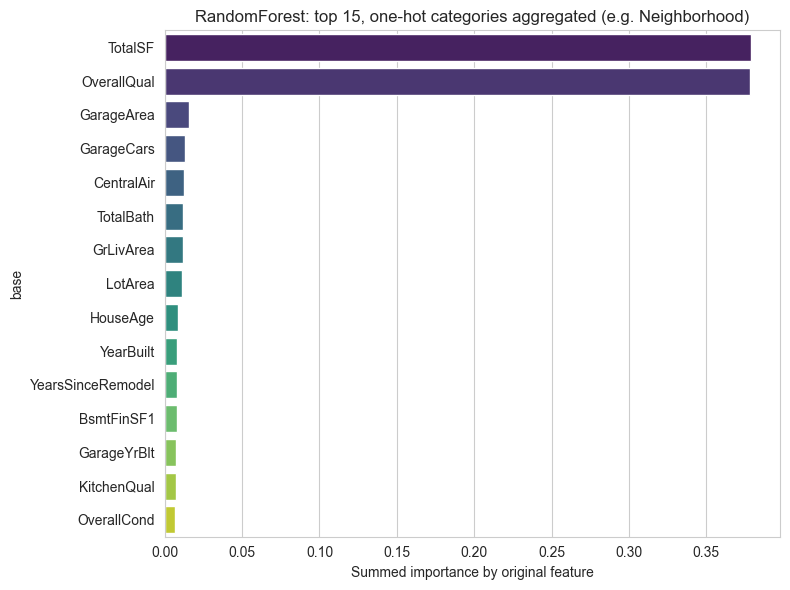

base
TotalSF              0.378699
OverallQual          0.378419
GarageArea           0.015406
GarageCars           0.012798
CentralAir           0.012248
TotalBath            0.011730
GrLivArea            0.011653
LotArea              0.011202
HouseAge             0.008463
YearBuilt            0.008213
YearsSinceRemodel    0.008162
BsmtFinSF1           0.008027
GarageYrBlt          0.007429
KitchenQual          0.007095
OverallCond          0.006821
Name: value, dtype: float64

In [4]:
rf_agg = aggregate_by_base_feature(rf_importances.values, base_names, agg="sum").sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=rf_agg.values, y=rf_agg.index, hue=rf_agg.index, palette="viridis", legend=False)
plt.xlabel("Summed importance by original feature")
plt.title("RandomForest: top 15, one-hot categories aggregated (e.g. Neighborhood)")
plt.tight_layout()
plt.show()

rf_agg

## 2. Ridge coefficients

Numeric features are standardized (`StandardScaler`), so their coefficients are directly comparable to each other. Ordinal and one-hot features aren't scaled, so their coefficients represent the effect in log-price units per category step / per category presence, which isn't quite the same thing as for numeric features — we compare within each group rather than across groups.

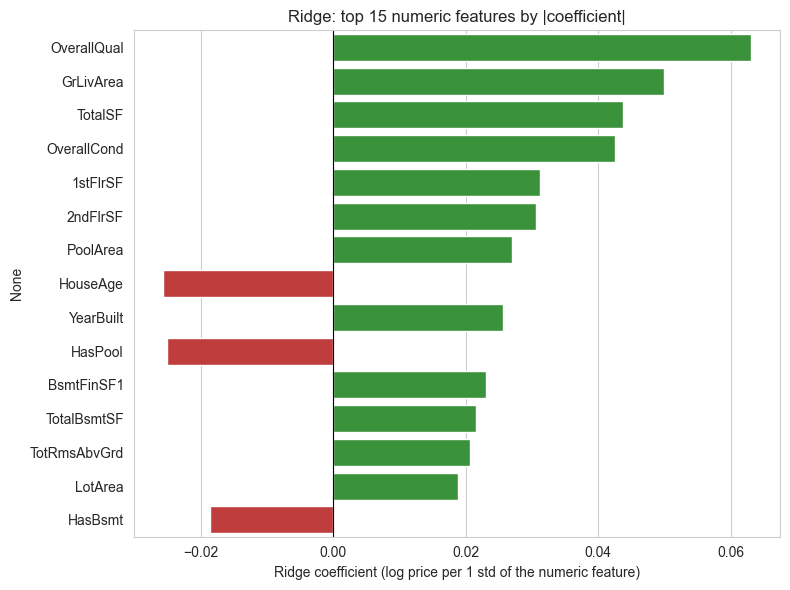

OverallQual     0.063032
GrLivArea       0.049979
TotalSF         0.043692
OverallCond     0.042593
1stFlrSF        0.031184
2ndFlrSF        0.030662
PoolArea        0.027045
HouseAge       -0.025749
YearBuilt       0.025626
HasPool        -0.025179
BsmtFinSF1      0.022999
TotalBsmtSF     0.021491
TotRmsAbvGrd    0.020638
LotArea         0.018898
HasBsmt        -0.018680
dtype: float64

In [5]:
ridge_pipe = pipelines["Ridge"]
ridge_ct = ridge_pipe.named_steps["preprocess"]
ridge_display_names, ridge_base_names = get_output_feature_names(ridge_ct)

n_num = len(ridge_ct.transformers_[0][2])  # numeric features are standardized -> coefficients are directly comparable
ridge_coefs = pd.Series(ridge_pipe.named_steps["model"].coef_, index=ridge_display_names)
ridge_numeric_top = ridge_coefs.iloc[:n_num].reindex(ridge_coefs.iloc[:n_num].abs().sort_values(ascending=False).index).head(15)

plt.figure(figsize=(8, 6))
colors = ["#2ca02c" if v > 0 else "#d62728" for v in ridge_numeric_top.values]
sns.barplot(x=ridge_numeric_top.values, y=ridge_numeric_top.index, hue=ridge_numeric_top.index, palette=colors, legend=False)
plt.xlabel("Ridge coefficient (log price per 1 std of the numeric feature)")
plt.title("Ridge: top 15 numeric features by |coefficient|")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

ridge_numeric_top

## 3. Permutation importance (more reliable than built-in) — on raw columns

Computed on the held-out 20%, not on the training data — otherwise the estimate would be optimistic/overfit. A feature is randomly shuffled and we look at how much worse the metric gets — the bigger the drop, the more important the feature. Here `Neighborhood` is a single column (not 25 one-hot dummies), which is much easier to interpret.

In [6]:
perm_importances = {}
for name, pipe in pipelines.items():
    perm_importances[name] = raw_permutation_importance(
        pipe, X_test, y_test, n_repeats=10, random_state=42,
        scoring="neg_root_mean_squared_error", n_jobs=-1,
    )
    print(f"{name} done")

perm_df = pd.DataFrame(perm_importances)
perm_df["mean_across_models"] = perm_df.mean(axis=1)
perm_top = perm_df.sort_values("mean_across_models", ascending=False).head(15)
perm_top

Ridge done


RandomForest done


HistGradientBoosting done


,Ridge,RandomForest,HistGradientBoosting,mean_across_models
OverallQual,0.036189,0.087632,0.072336,0.065385
2ndFlrSF,0.026211,0.058274,0.044478,0.042987
1stFlrSF,0.024463,0.054525,0.040732,0.039907
TotalBsmtSF,0.016445,0.058908,0.042985,0.039446
YearBuilt,0.024176,0.005289,0.007650,0.012371
OverallCond,0.019150,0.004304,0.010676,0.011377
GrLivArea,0.019150,0.002183,0.006666,0.009333
CentralAir,0.003235,0.006915,0.006421,0.005524
YearRemodAdd,0.003730,0.005295,0.004929,0.004651
MSZoning,0.007991,0.002087,0.003362,0.004480


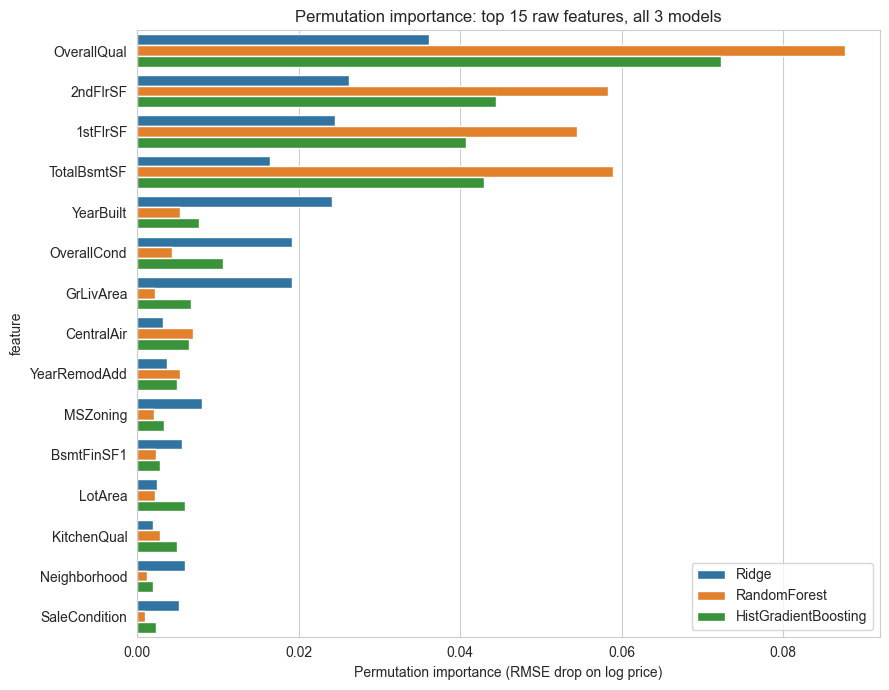

In [7]:
plot_df = perm_top.drop(columns="mean_across_models").reset_index().melt(id_vars="index", var_name="model", value_name="importance")
plot_df = plot_df.rename(columns={"index": "feature"})

plt.figure(figsize=(9, 7))
sns.barplot(data=plot_df, x="importance", y="feature", hue="model")
plt.xlabel("Permutation importance (RMSE drop on log price)")
plt.title("Permutation importance: top 15 raw features, all 3 models")
plt.legend(title=None)
plt.tight_layout()
plt.show()

## 4. Charts for a non-technical audience

Three simple, jargon-free charts: price vs. area, what matters most for price, and how accurate the model's predictions are.

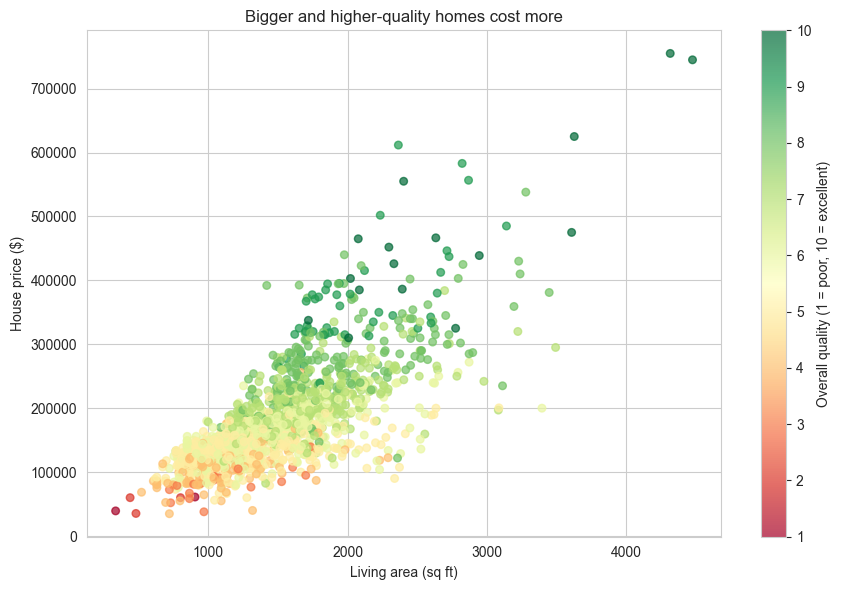

In [8]:
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    train_df["GrLivArea"], train_df["SalePrice"],
    c=train_df["OverallQual"], cmap="RdYlGn", alpha=0.7, s=30,
)
plt.colorbar(scatter, label="Overall quality (1 = poor, 10 = excellent)")
plt.xlabel("Living area (sq ft)")
plt.ylabel("House price ($)")
plt.title("Bigger and higher-quality homes cost more")
plt.tight_layout()
plt.show()

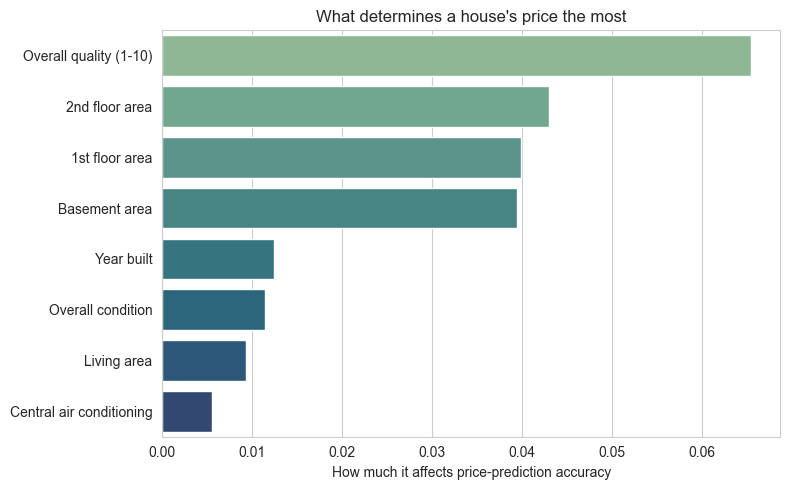

In [9]:
friendly_top = perm_df["mean_across_models"].sort_values(ascending=False).head(8)
friendly_labels = [HUMAN_LABELS.get(f, f) for f in friendly_top.index]

plt.figure(figsize=(8, 5))
sns.barplot(x=friendly_top.values, y=friendly_labels, hue=friendly_labels, palette="crest", legend=False)
plt.xlabel("How much it affects price-prediction accuracy")
plt.title("What determines a house's price the most")
plt.tight_layout()
plt.show()

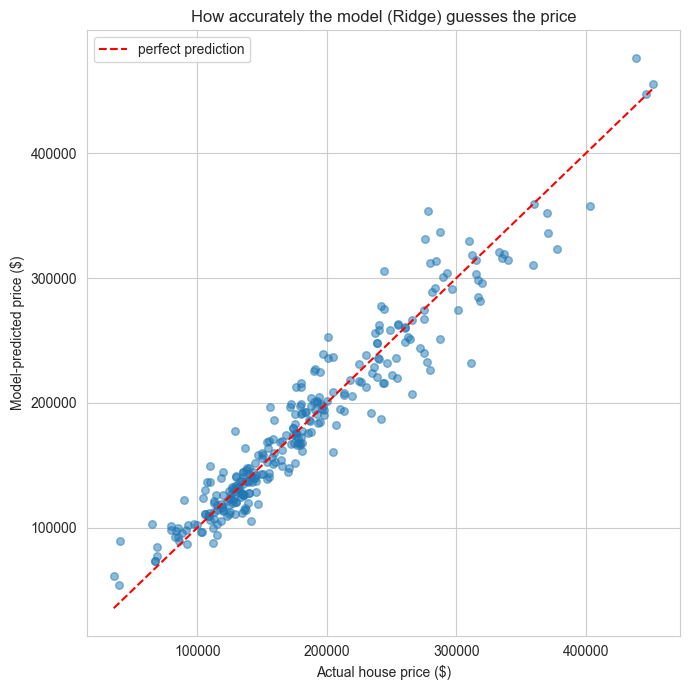

In [10]:
best_model_name = min(test_scores, key=lambda k: test_scores[k]["rmse_log"])
best_pipe = pipelines[best_model_name]

price_true = np.expm1(y_test)
price_pred = np.expm1(best_pipe.predict(X_test))

plt.figure(figsize=(7, 7))
plt.scatter(price_true, price_pred, alpha=0.5, s=30)
lims = [price_true.min(), price_true.max()]
plt.plot(lims, lims, color="red", linestyle="--", label="perfect prediction")
plt.xlabel("Actual house price ($)")
plt.ylabel("Model-predicted price ($)")
plt.title(f"How accurately the model ({best_model_name}) guesses the price")
plt.legend()
plt.tight_layout()
plt.show()

## Stage 5 conclusions

**Model quality on the held-out 20%** (for reference, consistent with the Stage 3 CV): Ridge — RMSE(log)=0.1233, R²=0.910; HistGradientBoosting — 0.1318, R²=0.897; RandomForest — 0.1430, R²=0.879. Ridge wins again — the same picture as under cross-validation.

**Top price drivers (permutation importance, averaged across 3 models, raw columns):**

| Feature | What it is | Importance |
|---|---|---|
| `OverallQual` | Overall quality | **0.065** (clear leader, #1 in all 3 models) |
| `2ndFlrSF` | 2nd floor area | 0.043 |
| `1stFlrSF` | 1st floor area | 0.040 |
| `TotalBsmtSF` | Basement area | 0.039 |
| `YearBuilt` | Year built | 0.012 |
| `OverallCond` | Overall condition | 0.011 |
| `GrLivArea` | Living area | 0.009 |
| `Neighborhood` | Neighborhood | ~0.002-0.006 |

1. **"Quality" and "size" from the resume were confirmed unambiguously.** `OverallQual` is the #1 feature across all three models, no exceptions. The "size" cluster (`2ndFlrSF`, `1stFlrSF`, `TotalBsmtSF`, `GrLivArea`, the engineered `TotalSF`) is, combined, the heaviest block of features: at the post-preprocessing level, `TotalSF` and `OverallQual` together account for ~76% of RandomForest's total importance.
2. **Important nuance: "size" is split across several correlated columns**, so individually `1stFlrSF`/`2ndFlrSF`/`TotalBsmtSF`/`GrLivArea` look more modest than a single unified "house size" signal would suggest. This is a textbook multicollinearity effect in permutation importance: shuffling one column (e.g. `1stFlrSF`) barely hurts the prediction because `TotalSF`/`GrLivArea` still carry almost the same size information. The engineered `TotalSF` feature and its Ridge coefficient (0.379, tied with `OverallQual`) make this much more visible than the scattered raw columns do.
3. **"Location" (Neighborhood) was only partially confirmed** — noticeably weaker than the naive "location, size, quality" expectation from the resume. `Neighborhood`'s marginal contribution (permutation importance ~0.002–0.006) is far more modest than `OverallQual` and the size cluster. Likely explanation: neighborhood correlates heavily with house size and quality (in expensive neighborhoods, homes are both bigger and better finished), so the model already "covers" part of the neighborhood effect through those features — leaving less unique, non-overlapping information for `Neighborhood` itself. An honest, not entirely expected, but valuable conclusion for the report: location matters, but is largely explained through size/quality rather than acting independently.
4. **The "price vs. area, colored by quality" chart** shows both main drivers at once, intuitively: price rises with area, and at the same area, higher-quality homes (green points) are consistently more expensive than lower-quality ones (red) — clear without any statistics.
5. **Predicted vs Actual for Ridge** (R²=0.91 on held-out data) sits tightly along the diagonal, with a bit more spread for expensive homes (>$400k) — those have the fewest training examples, a pattern we already noted back in Stage 1.

Next step — Stage 6: final repository write-up (README with charts and a results table; requirements.txt is already in place).